# Numbers Dataset Analysis

Analysis of synthetic numbers dataset for fine-tuning number recognition.

**What this checks:**
1. Split distribution
2. Style leakage (critical)
3. Number coverage
4. Format diversity
5. Style/bias distribution
6. Image quality
7. Visual samples

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [2]:
dataset_dir = Path('dataset_numbers')
manifest_path = dataset_dir / 'manifest.csv'

df = pd.read_csv(manifest_path)
print(f"{len(df)} total samples")
df.head()

911 total samples


,crop_path,text,split,field_type,style_id,bias
0,crops/price_00000.png,0,train,price,10,0.378
1,crops/price_00001.png,0,train,price,0,0.366
2,crops/price_00002.png,0,train,price,12,0.864
3,crops/price_00003.png,0,train,price,12,0.330
4,crops/price_00004.png,0,train,price,9,0.435


## 2. Split Distribution

split
train    767
test      75
val       69
Name: count, dtype: int64

Train: 84.2%
Val:   7.6%
Test:  8.2%


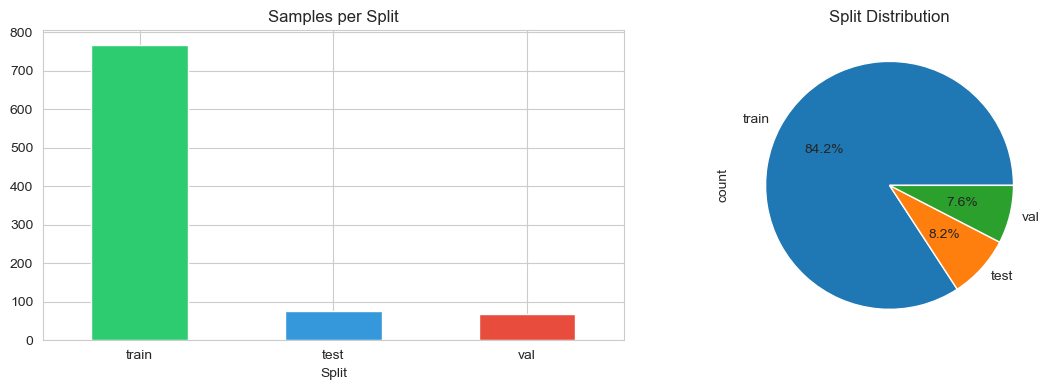

In [3]:
split_counts = df['split'].value_counts()
print(split_counts)
print(f"\nTrain: {split_counts.get('train', 0)/len(df)*100:.1f}%")
print(f"Val:   {split_counts.get('val', 0)/len(df)*100:.1f}%")
print(f"Test:  {split_counts.get('test', 0)/len(df)*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
split_counts.plot(kind='bar', ax=ax[0], color=['#2ecc71', '#3498db', '#e74c3c'])
ax[0].set_title('Samples per Split')
ax[0].set_xlabel('Split')
ax[0].tick_params(axis='x', rotation=0)

split_counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Split Distribution')
plt.tight_layout()
plt.show()

## 3. Style Leakage Check (Critical)

In [4]:
train_styles = set(df[df['split'] == 'train']['style_id'].unique())
val_styles = set(df[df['split'] == 'val']['style_id'].unique())
test_styles = set(df[df['split'] == 'test']['style_id'].unique())

print(f"Train styles: {sorted(train_styles)}")
print(f"Val styles:   {sorted(val_styles)}")
print(f"Test styles:  {sorted(test_styles)}")

train_val = train_styles & val_styles
train_test = train_styles & test_styles
val_test = val_styles & test_styles

print(f"\nTrain-Val overlap:  {train_val or '✓ None'}")
print(f"Train-Test overlap: {train_test or '✓ None'}")
print(f"Val-Test overlap:   {val_test or '✓ None'}")

if train_val or train_test or val_test:
    print("\n⚠️  WARNING: Style leakage detected!")
else:
    print("\n✓ PASS: Styles are disjoint")

Train styles: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Val styles:   [np.int64(6)]
Test styles:  [np.int64(7)]

Train-Val overlap:  ✓ None
Train-Test overlap: ✓ None
Val-Test overlap:   ✓ None

✓ PASS: Styles are disjoint


## 4. Number Format Analysis

Format distribution:
format
integer      304
comma        210
decimal_3    200
decimal_2    197
Name: count, dtype: int64

Unique numbers: 254


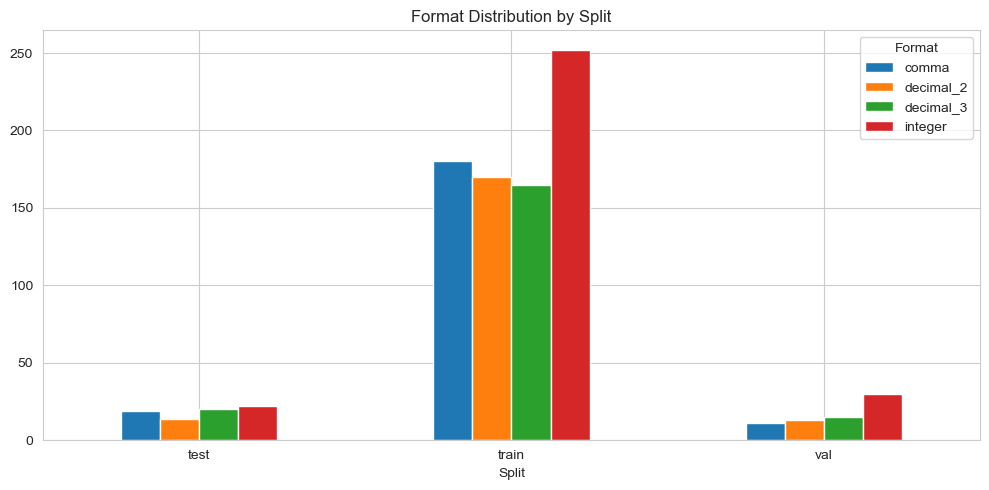

In [5]:
def categorize_number(text):
    text = str(text).strip()
    if ',' in text:
        return 'comma'
    elif '.' in text:
        decimals = len(text.split('.')[-1])
        return f'decimal_{decimals}'
    return 'integer'

df['format'] = df['text'].apply(categorize_number)
print("Format distribution:")
print(df['format'].value_counts())
print(f"\nUnique numbers: {df['text'].nunique()}")

pd.crosstab(df['split'], df['format']).plot(kind='bar', figsize=(10, 5))
plt.title('Format Distribution by Split')
plt.xlabel('Split')
plt.xticks(rotation=0)
plt.legend(title='Format')
plt.tight_layout()
plt.show()

## 5. Number Coverage

In [6]:
train_nums = set(df[df['split'] == 'train']['text'].unique())
val_nums = set(df[df['split'] == 'val']['text'].unique())
test_nums = set(df[df['split'] == 'test']['text'].unique())

print(f"Unique numbers per split:")
print(f"  Train: {len(train_nums)}")
print(f"  Val:   {len(val_nums)}")
print(f"  Test:  {len(test_nums)}")

val_only = val_nums - train_nums
test_only = test_nums - train_nums
print(f"\nVal only: {len(val_only)} numbers")
print(f"Test only: {len(test_only)} numbers")

Unique numbers per split:
  Train: 250
  Val:   64
  Test:  63

Val only: 4 numbers
Test only: 1 numbers


## 6. Image Quality Check

In [7]:
missing = []
sizes = []

for idx, row in df.iterrows():
    img_path = dataset_dir / row['crop_path']
    if not img_path.exists():
        missing.append(row['crop_path'])
        continue
    
    img = cv2.imread(str(img_path))
    if img is not None:
        sizes.append(img.shape[:2])

print(f"Total: {len(df)}")
print(f"Missing: {len(missing)}")
print(f"Valid: {len(sizes)}")

if sizes:
    heights, widths = zip(*sizes)
    print(f"\nAvg height: {np.mean(heights):.1f} px")
    print(f"Avg width:  {np.mean(widths):.1f} px")

Total: 911
Missing: 0
Valid: 911

Avg height: 114.3 px
Avg width:  253.9 px


## 7. Visual Samples

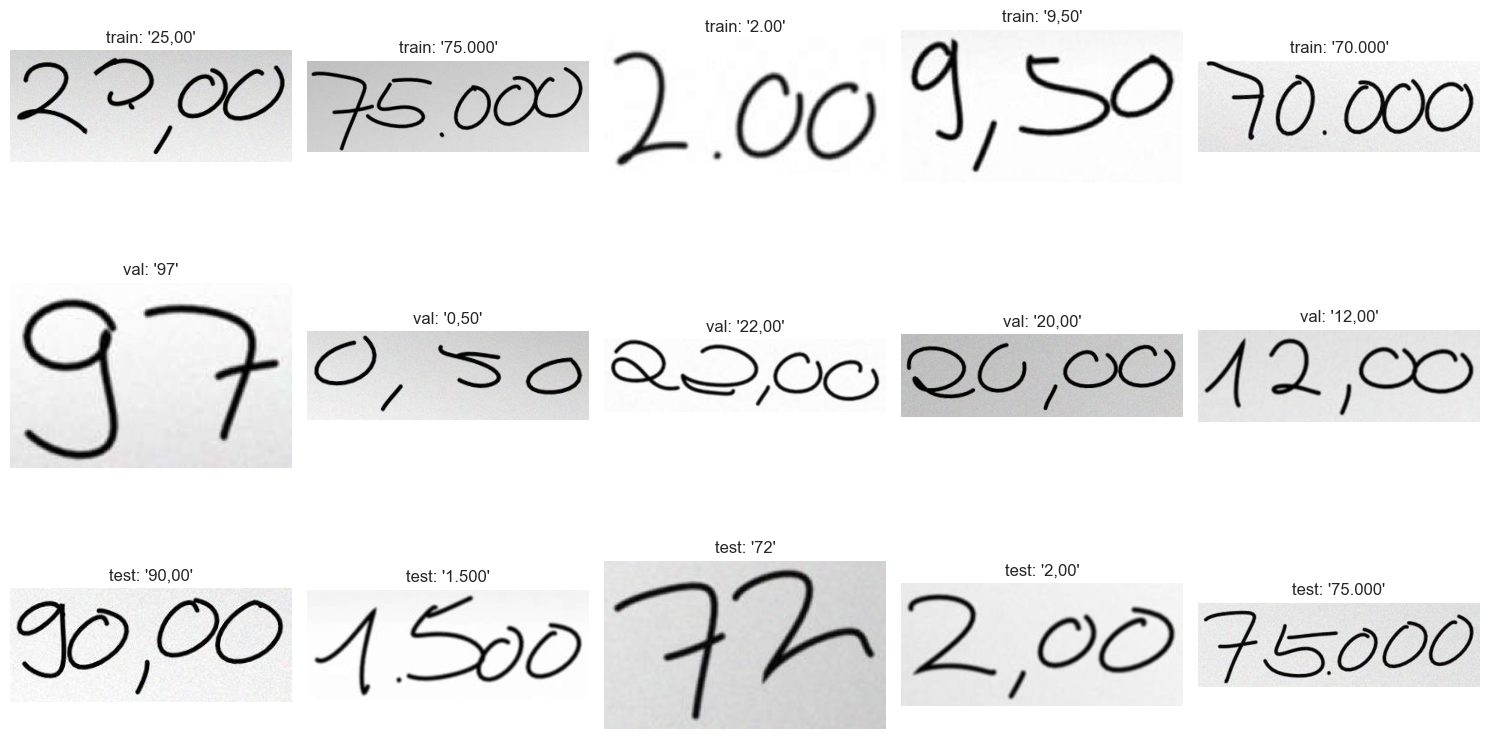

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for split_idx, split_name in enumerate(['train', 'val', 'test']):
    split_df = df[df['split'] == split_name].sample(min(5, len(df)))
    
    for i, (_, row) in enumerate(split_df.iterrows()):
        ax_idx = split_idx * 5 + i
        img_path = dataset_dir / row['crop_path']
        img = cv2.imread(str(img_path))
        
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[ax_idx].imshow(img_rgb)
            axes[ax_idx].set_title(f"{split_name}: '{row['text']}'")
        axes[ax_idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Summary

In [9]:
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Total samples: {len(df)}")
print(f"Unique numbers: {df['text'].nunique()}")
print(f"\nSplit distribution:")
for split in ['train', 'val', 'test']:
    count = len(df[df['split'] == split])
    print(f"  {split.capitalize():5s}: {count:4d} ({count/len(df)*100:.1f}%)")

print(f"\n✓ Dataset ready for training!")
print(f"\nNext step: Fine-tune with train_synthetic.py")

DATASET SUMMARY
Total samples: 911
Unique numbers: 254

Split distribution:
  Train:  767 (84.2%)
  Val  :   69 (7.6%)
  Test :   75 (8.2%)

✓ Dataset ready for training!

Next step: Fine-tune with train_synthetic.py
